In [1]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [2]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [3]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [4]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2560


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""04/03/2026""","""1278""","""21 28 36 22 24 16""","""41""","""49 32""","""Promoción Sí o Sí""","""162122242836""","[16, 21, … 36]",16,21,22,24,28,36,"""16""","""21""","""22""","""24""","""28""","""36""",null,null,null,null,null,null,false,0,"""05_01_02_04_08""",5,"""0""","""5""","""1""","""5""","""1""","""2""","""4""","""8""","""20""","""0""","""5""","""0"""
"""01/03/2026""","""1277""","""14 05 31 32 09 22""","""46""","""27 34""","""Promoción Sí o Sí""","""050914223132""","[5, 9, … 32]",5,9,14,22,31,32,"""05""","""09""","""14""","""22""","""31""","""32""","""16""","""21""","""22""","""24""","""28""","""36""",false,0,"""04_05_08_09_01""",-3,"""2""","""3""","""3""","""4""","""5""","""8""","""9""","""1""","""27""","""0""","""5""","""0"""
"""25/02/2026""","""1276""","""17 22 18 11 35 44""","""50""","""03""","""Promoción Sí o Sí""","""111718223544""","[11, 17, … 44]",11,17,18,22,35,44,"""11""","""17""","""18""","""22""","""35""","""44""","""05""","""09""","""14""","""22""","""31""","""32""",false,0,"""06_01_04_13_09""",-17,"""2""","""3""","""3""","""6""","""1""","""4""","""13""","""9""","""33""","""1""","""5""","""0"""
"""22/02/2026""","""1275""","""43 49 26 46 23 24""","""17""","""03 39 10""","""Promoción Sí o Sí""","""232426434649""","[23, 24, … 49]",23,24,26,43,46,49,"""23""","""24""","""26""","""43""","""46""","""49""","""11""","""17""","""18""","""22""","""35""","""44""",true,24,"""01_02_17_03_03""",86,"""2""","""3""","""3""","""1""","""2""","""17""","""3""","""3""","""26""","""1""","""4""","""1"""
"""18/02/2026""","""1274""","""02 32 42 33 07 22""","""30""","""01 19 09""","""Promoción Sí o Sí""","""020722323342""","[2, 7, … 42]",2,7,22,32,33,42,"""02""","""07""","""22""","""32""","""33""","""42""","""23""","""24""","""26""","""43""","""46""","""49""",true,16,"""05_15_10_01_09""",10,"""2""","""4""","""2""","""5""","""15""","""10""","""1""","""9""","""40""","""2""","""5""","""0"""
"""15/02/2026""","""1273""","""22 05 40 24 41 09""","""04""","""44 07 36""","""Promoción Sí o Sí""","""050922244041""","[5, 9, … 41]",5,9,22,24,40,41,"""05""","""09""","""22""","""24""","""40""","""41""","""02""","""07""","""22""","""32""","""33""","""42""",true,16,"""04_13_02_16_01""",-99,"""2""","""3""","""3""","""4""","""13""","""2""","""16""","""1""","""36""","""2""","""5""","""0"""
"""11/02/2026""","""1272""","""23 44 11 15 05 34""","""22""","""38 14 47""","""Promoción Sí o Sí""","""051115233444""","[5, 11, … 44]",5,11,15,23,34,44,"""05""","""11""","""15""","""23""","""34""","""44""","""05""","""09""","""22""","""24""","""40""","""41""",false,0,"""06_04_08_11_10""",4,"""3""","""2""","""4""","""6""","""4""","""8""","""11""","""10""","""39""","""2""","""5""","""0"""
"""08/02/2026""","""1271""","""15 24 28 23 05 41""","""50""","""39 27""","""Promoción Sí o Sí""","""051523242841""","[5, 15, … 41]",5,15,23,24,28,41,"""05""","""15""","""23""","""24""","""28""","""41""","""05""","""11""","""15""","""23""","""34""","""44""",false,0,"""10_08_01_04_13""",-19,"""3""","""2""","""4""","""10""","""8""","""1""","""4""","""13""","""36""","""2""","""5""","""0"""
"""04/02/2026""","""1270""","""27 18 25 38 07 43""","""09""","""04""","""Promoción Sí o Sí""","""071825273843""","[7, 18, … 43]",7,18,25,27,38,43,"""07""","""18""","""25""","""27""","""38""","""43""","""05""","""15""","""23""","""24""","""28""","""41""",false,0,"""11_07_02_11_05""",-44,"""2""","""2""","""4""","""11""","""7""","""2""","""11""","""5""","""36""","""2""","""4""","""0"""


In [5]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""04/03/2026""","""1278""","""21 28 36 22 24 16""","""41""","""49 32""","""Promoción Sí o Sí""","""162122242836""","[16, 21, … 36]",16,21,22,24,28,36,"""16""","""21""","""22""","""24""","""28""","""36""",null,null,null,null,null,null,false,0,"""05_01_02_04_08""",5,"""0""","""5""","""1""","""5""","""1""","""2""","""4""","""8""","""20""","""0""","""5""","""0"""
"""25/02/2026""","""1276""","""17 22 18 11 35 44""","""50""","""03""","""Promoción Sí o Sí""","""111718223544""","[11, 17, … 44]",11,17,18,22,35,44,"""11""","""17""","""18""","""22""","""35""","""44""","""05""","""09""","""14""","""22""","""31""","""32""",false,0,"""06_01_04_13_09""",-17,"""2""","""3""","""3""","""6""","""1""","""4""","""13""","""9""","""33""","""1""","""5""","""0"""
"""22/02/2026""","""1275""","""43 49 26 46 23 24""","""17""","""03 39 10""","""Promoción Sí o Sí""","""232426434649""","[23, 24, … 49]",23,24,26,43,46,49,"""23""","""24""","""26""","""43""","""46""","""49""","""11""","""17""","""18""","""22""","""35""","""44""",true,24,"""01_02_17_03_03""",86,"""2""","""3""","""3""","""1""","""2""","""17""","""3""","""3""","""26""","""1""","""4""","""1"""
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [6]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [7]:
dfRows.item(0, 'b2')

21

In [8]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [9]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='16'
df_viz FOR str_b1 = 16


post_str_b1,count,percent
str,u32,f64
"""01""",5,11.904762
"""03""",5,11.904762
"""05""",5,11.904762
"""02""",5,11.904762
"""08""",4,9.52381
…,…,…
"""13""",2,4.761905
"""15""",1,2.380952
"""10""",1,2.380952


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 16
Last 3 results last_results=['01', '13', '06']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""15/01/2025""","""1160""","""36 16 47 38 19 46""","""32""","""18 24 43 08""","""Promoción Sí o Sí""","""161936384647""","[16, 19, … 47]",16,19,36,38,46,47,"""16""","""19""","""36""","""38""","""46""","""47""","""01""","""02""","""05""","""23""","""44""","""45""",true,16,"""03_17_02_08_01""",-84,"""2""","""4""","""2""","""3""","""17""","""2""","""8""","""1""","""31""","""1""","""5""","""0"""
"""13/03/2024""","""1072""","""18 46 34 16 43 48""","""07""","""17 30 13 41""","""Promoción Sí o Sí""","""161834434648""","[16, 18, … 48]",16,18,34,43,46,48,"""16""","""18""","""34""","""43""","""46""","""48""","""13""","""17""","""19""","""24""","""34""","""41""",true,16,"""02_16_09_03_02""",-18,"""1""","""5""","""1""","""2""","""16""","""9""","""3""","""2""","""32""","""1""","""4""","""0"""
"""28/08/2022""","""0911""","""30 19 16 34 26 41""","""23""","""11 43""","""Promoción Sí o Sí""","""161926303441""","[16, 19, … 41]",16,19,26,30,34,41,"""16""","""19""","""26""","""30""","""34""","""41""","""06""","""09""","""15""","""24""","""36""","""37""",true,8,"""03_07_04_04_07""",-10,"""2""","""4""","""2""","""3""","""7""","""4""","""4""","""7""","""25""","""0""","""3""","""0"""
"""01/05/2022""","""0877""","""43 26 16 24 33 39""","""42""","""02 01 23""","""Promoción Sí o Sí""","""162426333943""","[16, 24, … 43]",16,24,26,33,39,43,"""16""","""24""","""26""","""33""","""39""","""43""","""02""","""09""","""12""","""23""","""33""","""41""",false,0,"""08_02_07_06_04""",22,"""1""","""3""","""3""","""8""","""2""","""7""","""6""","""4""","""27""","""0""","""5""","""0"""
"""03/10/2021""","""0817""","""32 16 39 22 29 30""","""37""","""""","""""","""162229303239""","[16, 22, … 39]",16,22,29,30,32,39,"""16""","""22""","""29""","""30""","""32""","""39""","""05""","""31""","""37""","""38""","""39""","""45""",false,0,"""06_07_01_02_07""",-17,"""1""","""4""","""2""","""6""","""7""","""1""","""2""","""7""","""23""","""0""","""4""","""0"""
"""25/08/2021""","""0806""","""42 23 32 16 45 19""","""17""","""""","""""","""161923324245""","[16, 19, … 45]",16,19,23,32,42,45,"""16""","""19""","""23""","""32""","""42""","""45""","""06""","""17""","""19""","""25""","""36""","""40""",false,0,"""03_04_09_10_03""",4,"""2""","""3""","""3""","""3""","""4""","""9""","""10""","""3""","""29""","""1""","""4""","""0"""
"""21/03/2021""","""0761""","""16 18 17 32 31 20""","""40""","""""","""""","""161718203132""","[16, 17, … 32]",16,17,18,20,31,32,"""16""","""17""","""18""","""20""","""31""","""32""","""03""","""04""","""16""","""27""","""29""","""42""",true,8,"""01_01_02_11_01""",-34,"""2""","""4""","""2""","""1""","""1""","""2""","""11""","""1""","""16""","""1""","""3""","""1"""
"""09/02/2020""","""0678""","""35 28 19 16 37 21""","""09""","""""","""""","""161921283537""","[16, 19, … 37]",16,19,21,28,35,37,"""16""","""19""","""21""","""28""","""35""","""37""","""09""","""25""","""26""","""27""","""29""","""33""",true,8,"""03_02_07_07_02""",11,"""2""","""2""","""4""","""3""","""2""","""7""","""7""","""2""","""21""","""0""","""3""","""1"""
"""17/04/2019""","""0593""","""34 21 23 26 18 16""","""44""","""""","""""","""161821232634""","[16, 18, … 34]",16,18,21,23,26,34,"""16""","""18""","""21""","""23""","""26""","""34""","""07""","""09""","""11""","""14""","""26""","""36""",false,0,"""02_03_02_03_08""",-2,"""1""","""4""","""2""","""2""","""3""","""2""","""3""","""8""","""18""","""0""","""3""","""1"""


df_jumps_map FOR str_b1 = 16


jumps_map,count
str,u32
"""05_05_02_12_05""",1
"""02_07_01_02_17""",1
"""01_01_17_05_02""",1
"""06_01_09_09_04""",1
"""03_02_11_03_04""",1
…,…
"""03_07_04_04_07""",1
"""01_09_02_13_01""",1
"""01_11_03_01_07""",1


df_unijump FOR str_b1 = 16


unijump,count
i64,u32
4,3
-23,2
24,2
-17,2
-26,2
…,…
-11,1
-5,1
13,1


In [10]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='21'
df_viz FOR str_b2 = 21


post_str_b2,count,percent
str,u32,f64
"""10""",7,10.606061
"""07""",6,9.090909
"""19""",5,7.575758
"""08""",5,7.575758
"""15""",4,6.060606
…,…,…
"""13""",1,1.515152
"""29""",1,1.515152
"""28""",1,1.515152


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 21
Last 3 results last_results=['18', '19', '07']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""10/12/2025""","""1254""","""36 21 07 38 47 48""","""03""","""23 01 50""","""Promoción Sí o Sí""","""072136384748""","[7, 21, … 48]",7,21,36,38,47,48,"""07""","""21""","""36""","""38""","""47""","""48""","""14""","""19""","""27""","""35""","""37""","""50""",false,0,"""14_15_02_09_01""",-69,"""2""","""3""","""3""","""14""","""15""","""2""","""9""","""1""","""41""","""2""","""5""","""0"""
"""19/11/2025""","""1248""","""28 40 02 44 21 33""","""15""","""25""","""Promoción Sí o Sí""","""022128334044""","[2, 21, … 44]",2,21,28,33,40,44,"""02""","""21""","""28""","""33""","""40""","""44""","""03""","""07""","""10""","""12""","""45""","""49""",false,0,"""19_07_05_07_04""",-3,"""1""","""4""","""2""","""19""","""7""","""5""","""7""","""4""","""42""","""1""","""4""","""0"""
"""12/10/2025""","""1237""","""42 21 47 10 24 38""","""18""","""46 17 20""","""Promoción Sí o Sí""","""102124384247""","[10, 21, … 47]",10,21,24,38,42,47,"""10""","""21""","""24""","""38""","""42""","""47""","""12""","""18""","""31""","""42""","""43""","""45""",false,0,"""11_03_14_04_05""",72,"""1""","""4""","""2""","""11""","""3""","""14""","""4""","""5""","""37""","""2""","""5""","""0"""
"""06/08/2025""","""1218""","""38 23 06 21 33 36""","""16""","""49 07""","""Promoción Sí o Sí""","""062123333638""","[6, 21, … 38]",6,21,23,33,36,38,"""06""","""21""","""23""","""33""","""36""","""38""","""19""","""24""","""25""","""29""","""46""","""47""",false,0,"""15_02_10_03_02""",57,"""1""","""3""","""3""","""15""","""2""","""10""","""3""","""2""","""32""","""2""","""4""","""0"""
"""11/05/2025""","""1193""","""46 21 49 45 03 43""","""17""","""20 30 32 44""","""Promoción Sí o Sí""","""032143454649""","[3, 21, … 49]",3,21,43,45,46,49,"""03""","""21""","""43""","""45""","""46""","""49""","""04""","""07""","""09""","""12""","""13""","""38""",false,0,"""18_22_02_01_03""",-59,"""2""","""1""","""5""","""18""","""22""","""2""","""1""","""3""","""46""","""2""","""5""","""1"""
"""18/09/2024""","""1126""","""26 10 34 37 21 32""","""45""","""20 15""","""Promoción Sí o Sí""","""102126323437""","[10, 21, … 37]",10,21,26,32,34,37,"""10""","""21""","""26""","""32""","""34""","""37""","""04""","""17""","""20""","""37""","""38""","""48""",false,0,"""11_05_06_02_03""",22,"""1""","""4""","""2""","""11""","""5""","""6""","""2""","""3""","""27""","""1""","""5""","""0"""
"""22/05/2024""","""1092""","""21 31 47 15 39 33""","""01""","""28 43""","""Promoción Sí o Sí""","""152131333947""","[15, 21, … 47]",15,21,31,33,39,47,"""15""","""21""","""31""","""33""","""39""","""47""","""18""","""20""","""25""","""27""","""29""","""39""",true,2,"""06_10_02_06_08""",-38,"""2""","""0""","""6""","""6""","""10""","""2""","""6""","""8""","""32""","""1""","""4""","""0"""
"""17/04/2024""","""1082""","""47 40 26 21 06 27""","""34""","""35 11""","""Promoción Sí o Sí""","""062126274047""","[6, 21, … 47]",6,21,26,27,40,47,"""06""","""21""","""26""","""27""","""40""","""47""","""02""","""15""","""16""","""29""","""34""","""36""",true,16,"""15_05_01_13_07""",-44,"""1""","""3""","""3""","""15""","""5""","""1""","""13""","""7""","""41""","""2""","""5""","""0"""
"""24/03/2024""","""1075""","""32 21 09 48 25 28""","""39""","""22""","""Promoción Sí o Sí""","""092125283248""","[9, 21, … 48]",9,21,25,28,32,48,"""09""","""21""","""25""","""28""","""32""","""48""","""06""","""11""","""16""","""19""","""23""","""30""",false,0,"""12_04_03_04_16""",14,"""0""","""3""","""3""","""12""","""4""","""3""","""4""","""16""","""39""","""2""","""4""","""0"""


df_jumps_map FOR str_b2 = 21


jumps_map,count
str,u32
"""18_04_01_11_01""",1
"""18_02_12_09_01""",1
"""08_05_09_02_08""",1
"""11_03_14_04_05""",1
"""15_02_03_14_01""",1
…,…
"""12_13_04_01_03""",1
"""09_03_09_03_05""",1
"""11_01_04_07_05""",1


df_unijump FOR str_b2 = 21


unijump,count
i64,u32
3,3
-17,2
20,2
4,2
8,2
…,…
-35,1
46,1
9,1


In [11]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='22'
df_viz FOR str_b3 = 22


post_str_b3,count,percent
str,u32,f64
"""19""",7,7.291667
"""17""",6,6.25
"""18""",6,6.25
"""11""",5,5.208333
"""16""",5,5.208333
…,…,…
"""09""",2,2.083333
"""36""",2,2.083333
"""04""",1,1.041667


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 22
Last 3 results last_results=['26', '22', '25']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""18/02/2026""","""1274""","""02 32 42 33 07 22""","""30""","""01 19 09""","""Promoción Sí o Sí""","""020722323342""","[2, 7, … 42]",2,7,22,32,33,42,"""02""","""07""","""22""","""32""","""33""","""42""","""23""","""24""","""26""","""43""","""46""","""49""",true,16,"""05_15_10_01_09""",10,"""2""","""4""","""2""","""5""","""15""","""10""","""1""","""9""","""40""","""2""","""5""","""0"""
"""15/02/2026""","""1273""","""22 05 40 24 41 09""","""04""","""44 07 36""","""Promoción Sí o Sí""","""050922244041""","[5, 9, … 41]",5,9,22,24,40,41,"""05""","""09""","""22""","""24""","""40""","""41""","""02""","""07""","""22""","""32""","""33""","""42""",true,16,"""04_13_02_16_01""",-99,"""2""","""3""","""3""","""4""","""13""","""2""","""16""","""1""","""36""","""2""","""5""","""0"""
"""05/01/2025""","""1157""","""18 49 45 13 35 22""","""21""","""19 07 36 08""","""Promoción Sí o Sí""","""131822354549""","[13, 18, … 49]",13,18,22,35,45,49,"""13""","""18""","""22""","""35""","""45""","""49""","""20""","""24""","""25""","""40""","""44""","""47""",false,0,"""05_04_13_10_04""",31,"""1""","""2""","""4""","""5""","""4""","""13""","""10""","""4""","""36""","""2""","""4""","""0"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1""","""5""","""0"""
"""06/03/2024""","""1070""","""30 22 04 07 39 37""","""38""","""43 02 18""","""Promoción Sí o Sí""","""040722303739""","[4, 7, … 39]",4,7,22,30,37,39,"""04""","""07""","""22""","""30""","""37""","""39""","""12""","""18""","""30""","""32""","""34""","""35""",true,16,"""03_15_08_07_02""",-35,"""2""","""3""","""3""","""3""","""15""","""8""","""7""","""2""","""35""","""1""","""5""","""0"""
"""25/10/2023""","""1032""","""38 17 22 26 21 36""","""07""","""27 29 11""","""Promoción Sí o Sí""","""172122263638""","[17, 21, … 38]",17,21,22,26,36,38,"""17""","""21""","""22""","""26""","""36""","""38""","""06""","""10""","""11""","""19""","""36""","""39""",false,0,"""04_01_04_10_02""",-14,"""1""","""4""","""2""","""4""","""1""","""4""","""10""","""2""","""21""","""1""","""4""","""1"""
"""12/04/2023""","""0976""","""22 25 38 08 33 06""","""12""","""20""","""Promoción Sí o Sí""","""060822253338""","[6, 8, … 38]",6,8,22,25,33,38,"""06""","""08""","""22""","""25""","""33""","""38""","""04""","""13""","""15""","""20""","""40""","""46""",true,16,"""02_14_03_08_05""",-63,"""0""","""4""","""2""","""2""","""14""","""3""","""8""","""5""","""32""","""1""","""5""","""0"""
"""19/02/2023""","""0961""","""19 34 36 44 22 06""","""39""","""41 07""","""Promoción Sí o Sí""","""061922343644""","[6, 19, … 44]",6,19,22,34,36,44,"""06""","""19""","""22""","""34""","""36""","""44""","""03""","""04""","""19""","""24""","""29""","""43""",false,0,"""13_03_12_02_08""",73,"""1""","""5""","""1""","""13""","""3""","""12""","""2""","""8""","""38""","""2""","""5""","""0"""
"""30/10/2022""","""0929""","""44 22 10 30 14 35""","""32""","""19""","""Promoción Sí o Sí""","""101422303544""","[10, 14, … 44]",10,14,22,30,35,44,"""10""","""14""","""22""","""30""","""35""","""44""","""03""","""13""","""16""","""21""","""25""","""29""",true,8,"""04_08_08_05_09""",9,"""0""","""5""","""1""","""4""","""8""","""8""","""5""","""9""","""34""","""0""","""4""","""0"""


df_jumps_map FOR str_b3 = 22


jumps_map,count
str,u32
"""07_05_01_12_10""",1
"""08_09_04_04_07""",1
"""12_05_04_07_09""",1
"""16_01_18_03_01""",1
"""02_12_04_08_04""",1
…,…
"""04_14_16_04_01""",1
"""05_04_13_10_04""",1
"""02_12_06_03_05""",1


df_unijump FOR str_b3 = 22


unijump,count
i64,u32
8,3
-27,3
-42,3
-3,2
-10,2
…,…
37,1
60,1
-13,1


In [12]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='24'
df_viz FOR str_b4 = 24


post_str_b4,count,percent
str,u32,f64
"""23""",8,6.61157
"""33""",7,5.785124
"""32""",7,5.785124
"""26""",7,5.785124
"""18""",7,5.785124
…,…,…
"""24""",2,1.652893
"""14""",2,1.652893
"""22""",1,0.826446


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 24
Last 3 results last_results=['16', '32', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""15/02/2026""","""1273""","""22 05 40 24 41 09""","""04""","""44 07 36""","""Promoción Sí o Sí""","""050922244041""","[5, 9, … 41]",5,9,22,24,40,41,"""05""","""09""","""22""","""24""","""40""","""41""","""02""","""07""","""22""","""32""","""33""","""42""",true,16,"""04_13_02_16_01""",-99,"""2""","""3""","""3""","""4""","""13""","""2""","""16""","""1""","""36""","""2""","""5""","""0"""
"""08/02/2026""","""1271""","""15 24 28 23 05 41""","""50""","""39 27""","""Promoción Sí o Sí""","""051523242841""","[5, 15, … 41]",5,15,23,24,28,41,"""05""","""15""","""23""","""24""","""28""","""41""","""05""","""11""","""15""","""23""","""34""","""44""",false,0,"""10_08_01_04_13""",-19,"""3""","""2""","""4""","""10""","""8""","""1""","""4""","""13""","""36""","""2""","""5""","""0"""
"""24/12/2025""","""1258""","""16 13 31 08 24 33""","""01""","""45 11 22""","""Promoción Sí o Sí""","""081316243133""","[8, 13, … 33]",8,13,16,24,31,33,"""08""","""13""","""16""","""24""","""31""","""33""","""06""","""11""","""13""","""16""","""22""","""31""",false,0,"""05_03_08_07_02""",15,"""2""","""3""","""3""","""5""","""3""","""8""","""7""","""2""","""25""","""0""","""5""","""0"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""
"""23/03/2025""","""1179""","""24 07 18 03 37 49""","""43""","""50 28""","""Promoción Sí o Sí""","""030718243749""","[3, 7, … 49]",3,7,18,24,37,49,"""03""","""07""","""18""","""24""","""37""","""49""","""01""","""05""","""13""","""35""","""37""","""43""",false,0,"""04_11_06_13_12""",-44,"""3""","""2""","""4""","""4""","""11""","""6""","""13""","""12""","""46""","""3""","""5""","""0"""
"""22/12/2024""","""1153""","""17 02 49 40 24 01""","""45""","""14 22 05""","""Promoción Sí o Sí""","""010217244049""","[1, 2, … 49]",1,2,17,24,40,49,"""01""","""02""","""17""","""24""","""40""","""49""","""02""","""05""","""14""","""15""","""24""","""39""",true,16,"""01_15_07_16_09""",-72,"""2""","""3""","""3""","""1""","""15""","""7""","""16""","""9""","""48""","""2""","""5""","""0"""
"""03/11/2024""","""1139""","""04 24 37 36 14 02""","""03""","""50 12 42 10""","""Promoción Sí o Sí""","""020414243637""","[2, 4, … 37]",2,4,14,24,36,37,"""02""","""04""","""14""","""24""","""36""","""37""","""02""","""15""","""17""","""40""","""46""","""48""",true,8,"""02_10_10_12_01""",-25,"""2""","""5""","""1""","""2""","""10""","""10""","""12""","""1""","""35""","""3""","""4""","""0"""
"""20/10/2024""","""1135""","""08 50 24 33 10 15""","""49""","""25 01 14""","""Promoción Sí o Sí""","""081015243350""","[8, 10, … 50]",8,10,15,24,33,50,"""08""","""10""","""15""","""24""","""33""","""50""","""01""","""09""","""16""","""28""","""40""","""46""",true,8,"""02_05_09_09_17""",17,"""0""","""4""","""2""","""2""","""5""","""9""","""9""","""17""","""42""","""1""","""4""","""0"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1""","""5""","""0"""


df_jumps_map FOR str_b4 = 24


jumps_map,count
str,u32
"""05_02_07_16_03""",1
"""04_10_08_14_03""",1
"""04_07_09_05_02""",1
"""13_03_01_02_03""",1
"""03_06_09_12_01""",1
…,…
"""01_04_18_14_05""",1
"""03_03_08_01_13""",1
"""07_02_03_06_03""",1


df_unijump FOR str_b4 = 24


unijump,count
i64,u32
-10,3
44,3
-25,3
-22,3
-19,3
…,…
10,1
13,1
-64,1


In [13]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='28'
df_viz FOR str_b5 = 28


post_str_b5,count,percent
str,u32,f64
"""39""",9,8.823529
"""35""",8,7.843137
"""37""",7,6.862745
"""29""",6,5.882353
"""36""",6,5.882353
…,…,…
"""17""",1,0.980392
"""45""",1,0.980392
"""10""",1,0.980392


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 28
Last 3 results last_results=['34', '30', '45']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""08/02/2026""","""1271""","""15 24 28 23 05 41""","""50""","""39 27""","""Promoción Sí o Sí""","""051523242841""","[5, 15, … 41]",5,15,23,24,28,41,"""05""","""15""","""23""","""24""","""28""","""41""","""05""","""11""","""15""","""23""","""34""","""44""",false,0,"""10_08_01_04_13""",-19,"""3""","""2""","""4""","""10""","""8""","""1""","""4""","""13""","""36""","""2""","""5""","""0"""
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""
"""02/02/2025""","""1165""","""20 48 14 12 28 04""","""02""","""40""","""Promoción Sí o Sí""","""041214202848""","[4, 12, … 48]",4,12,14,20,28,48,"""04""","""12""","""14""","""20""","""28""","""48""","""12""","""19""","""24""","""27""","""30""","""33""",true,20,"""08_02_06_08_20""",24,"""0""","""6""","""0""","""8""","""2""","""6""","""8""","""20""","""44""","""1""","""4""","""0"""
"""13/10/2024""","""1133""","""31 17 28 09 21 05""","""08""","""22 27""","""Promoción Sí o Sí""","""050917212831""","[5, 9, … 31]",5,9,17,21,28,31,"""05""","""09""","""17""","""21""","""28""","""31""","""08""","""10""","""12""","""29""","""31""","""47""",false,0,"""04_08_04_07_03""",-29,"""3""","""1""","""5""","""4""","""8""","""4""","""7""","""3""","""26""","""0""","""4""","""0"""
"""31/12/2023""","""1051""","""35 28 15 23 27 09""","""14""","""45 32 40""","""Promoción Sí o Sí""","""091523272835""","[9, 15, … 35]",9,15,23,27,28,35,"""09""","""15""","""23""","""27""","""28""","""35""","""04""","""12""","""15""","""28""","""35""","""39""",false,0,"""06_08_04_01_07""",1,"""1""","""1""","""5""","""6""","""8""","""4""","""1""","""7""","""26""","""0""","""5""","""0"""
"""01/10/2023""","""1025""","""28 04 10 26 18 41""","""13""","""29 11""","""Promoción Sí o Sí""","""041018262841""","[4, 10, … 41]",4,10,18,26,28,41,"""04""","""10""","""18""","""26""","""28""","""41""","""05""","""09""","""16""","""22""","""38""","""41""",true,24,"""06_08_08_02_13""",27,"""1""","""5""","""1""","""6""","""8""","""8""","""2""","""13""","""37""","""1""","""4""","""0"""
"""27/08/2023""","""1015""","""20 22 38 28 16 14""","""36""","""34 43 08""","""Promoción Sí o Sí""","""141620222838""","[14, 16, … 38]",14,16,20,22,28,38,"""14""","""16""","""20""","""22""","""28""","""38""","""01""","""12""","""25""","""28""","""33""","""44""",true,4,"""02_04_02_06_10""",-16,"""0""","""6""","""0""","""2""","""4""","""2""","""6""","""10""","""24""","""1""","""4""","""0"""
"""05/07/2023""","""1000""","""34 28 11 01 24 05""","""30""","""42 39 44 09 32""","""Promoción Sí o Sí""","""010511242834""","[1, 5, … 34]",1,5,11,24,28,34,"""01""","""05""","""11""","""24""","""28""","""34""","""06""","""11""","""21""","""26""","""29""","""38""",false,0,"""04_06_13_04_06""",48,"""2""","""3""","""3""","""4""","""6""","""13""","""4""","""6""","""33""","""1""","""3""","""0"""
"""19/03/2023""","""0969""","""20 25 22 35 23 28""","""42""","""27 01 03""","""Promoción Sí o Sí""","""202223252835""","[20, 22, … 35]",20,22,23,25,28,35,"""20""","""22""","""23""","""25""","""28""","""35""","""01""","""16""","""27""","""29""","""31""","""40""",true,16,"""02_01_02_03_07""",5,"""1""","""3""","""3""","""2""","""1""","""2""","""3""","""7""","""15""","""0""","""4""","""0"""


df_jumps_map FOR str_b5 = 28


jumps_map,count
str,u32
"""08_07_02_06_06""",2
"""03_06_03_05_08""",1
"""12_02_01_06_07""",1
"""01_08_14_03_07""",1
"""06_01_05_02_16""",1
…,…
"""04_04_04_04_03""",1
"""07_05_12_03_13""",1
"""13_07_06_01_10""",1


df_unijump FOR str_b5 = 28


unijump,count
i64,u32
-26,4
-23,3
-15,3
40,3
4,3
…,…
-14,1
71,1
-39,1


In [14]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='36'
df_viz FOR str_b6 = 36


post_str_blast,count,percent
str,u32,f64
"""45""",15,12.5
"""43""",14,11.666667
"""34""",11,9.166667
"""36""",11,9.166667
"""41""",10,8.333333
…,…,…
"""47""",1,0.833333
"""29""",1,0.833333
"""26""",1,0.833333


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 36
Last 3 results last_results=['43', '37', '33']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""
"""30/04/2025""","""1190""","""11 36 33 06 02 16""","""37""","""14 07 10 01""","""Promoción Sí o Sí""","""020611163336""","[2, 6, … 36]",2,6,11,16,33,36,"""02""","""06""","""11""","""16""","""33""","""36""","""09""","""10""","""15""","""19""","""35""","""37""",true,8,"""04_05_05_17_03""",-51,"""2""","""4""","""2""","""4""","""5""","""5""","""17""","""3""","""34""","""1""","""4""","""0"""
"""20/11/2024""","""1144""","""36 27 28 26 29 03""","""10""","""44 39 45""","""Promoción Sí o Sí""","""032627282936""","[3, 26, … 36]",3,26,27,28,29,36,"""03""","""26""","""27""","""28""","""29""","""36""","""05""","""19""","""26""","""29""","""45""","""46""",true,24,"""23_01_01_01_07""",28,"""2""","""3""","""3""","""23""","""1""","""1""","""1""","""7""","""33""","""1""","""3""","""0"""
"""21/04/2024""","""1083""","""29 02 16 36 34 15""","""39""","""13 38""","""Promoción Sí o Sí""","""021516293436""","[2, 15, … 36]",2,15,16,29,34,36,"""02""","""15""","""16""","""29""","""34""","""36""","""04""","""05""","""24""","""26""","""37""","""43""",false,0,"""13_01_13_05_02""",69,"""2""","""4""","""2""","""13""","""1""","""13""","""5""","""2""","""34""","""2""","""4""","""1"""
"""10/01/2024""","""1054""","""29 01 11 10 36 30""","""31""","""38 23 20 40""","""Promoción Sí o Sí""","""011011293036""","[1, 10, … 36]",1,10,11,29,30,36,"""01""","""10""","""11""","""29""","""30""","""36""","""20""","""27""","""28""","""41""","""44""","""47""",false,0,"""09_01_18_01_06""",115,"""2""","""3""","""3""","""9""","""1""","""18""","""1""","""6""","""35""","""1""","""4""","""0"""
"""20/07/2022""","""0900""","""09 08 18 36 31 24""","""42""","""33 01""","""Promoción Sí o Sí""","""080918243136""","[8, 9, … 36]",8,9,18,24,31,36,"""08""","""09""","""18""","""24""","""31""","""36""","""03""","""04""","""07""","""12""","""23""","""31""",false,0,"""01_09_06_07_05""",-22,"""1""","""4""","""2""","""1""","""9""","""6""","""7""","""5""","""28""","""0""","""5""","""0"""
"""05/06/2022""","""0887""","""29 32 12 03 36 06""","""25""","""05 01 04""","""Promoción Sí o Sí""","""030612293236""","[3, 6, … 36]",3,6,12,29,32,36,"""03""","""06""","""12""","""29""","""32""","""36""","""07""","""12""","""19""","""30""","""40""","""41""",false,0,"""03_06_17_03_04""",73,"""2""","""4""","""2""","""3""","""6""","""17""","""3""","""4""","""33""","""1""","""4""","""0"""
"""03/04/2022""","""0869""","""04 35 34 08 05 36""","""30""","""19 14""","""Promoción Sí o Sí""","""040508343536""","[4, 5, … 36]",4,5,8,34,35,36,"""04""","""05""","""08""","""34""","""35""","""36""","""05""","""10""","""13""","""15""","""18""","""31""",true,24,"""01_03_26_01_01""",142,"""1""","""4""","""2""","""1""","""3""","""26""","""1""","""1""","""32""","""1""","""3""","""0"""


df_jumps_map FOR str_b6 = 36


jumps_map,count
str,u32
"""03_01_05_06_15""",1
"""10_01_02_04_14""",1
"""01_07_02_18_06""",1
"""04_05_05_17_03""",1
"""07_03_01_03_21""",1
…,…
"""01_03_09_18_04""",1
"""05_02_08_05_01""",1
"""06_09_14_01_05""",1


df_unijump FOR str_b6 = 36


unijump,count
i64,u32
55,4
28,4
-19,4
18,3
-51,3
…,…
-27,1
36,1
26,1


In [15]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [16]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [17]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 6, 1, 8, 15, 13, 7, 14]
int_jcounts=[2, 3, 1, 5, 4, 6, 10, 11, 8]
int_jcounts=[2, 1, 3, 4, 8, 6, 9, 5, 7, 11, 17, 10]
int_jcounts=[4, 1, 2, 3, 5, 8, 6, 9, 7, 16]
int_jcounts=[2, 1, 3, 9, 10, 6, 5, 7, 11]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['36', '44', '42', '46', '35', '39', '37', '40', '26', '33', '41', '32', '28', '29', '30']


In [18]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_js = dfRows[0:10]

last_j1 = list(set(last_js["j1"].to_list()))
last_j2 = list(set(last_js["j2"].to_list()))
last_j3 = list(set(last_js["j3"].to_list()))
last_j4 = list(set(last_js["j4"].to_list()))
last_j5 = list(set(last_js["j5"].to_list()))
last_jsum = list(set(last_js["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["03", "04", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  # ~pl.col("j1").is_in(last_j1),
  # ~pl.col("j2").is_in(last_j2),
  # ~pl.col("j3").is_in(last_j3),
  # ~pl.col("j4").is_in(last_j4),
  # ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
yyyymmdd = today.strftime("%Y%m%d")

df_possible.write_excel(f"./df_possible_v4_{yyyymmdd}.xlsx")

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""030406092435""","[3, 4, … 35]",3,4,6,9,24,35,"""03""","""04""","""06""","""09""","""24""","""35""","""03""","""34""",true,16,"""01_02_03_15_11""",-38,"""1""","""3""","""3""","""1""","""2""","""3""","""15""","""11""","""32""","""2""","""5""","""0"""
"""030406092535""","[3, 4, … 35]",3,4,6,9,25,35,"""03""","""04""","""06""","""09""","""25""","""35""","""03""","""34""",true,16,"""01_02_03_16_10""",-43,"""1""","""2""","""4""","""1""","""2""","""3""","""16""","""10""","""32""","""2""","""5""","""0"""
"""030406102435""","[3, 4, … 35]",3,4,6,10,24,35,"""03""","""04""","""06""","""10""","""24""","""35""","""03""","""34""",false,0,"""01_02_04_14_11""",-28,"""1""","""4""","""2""","""1""","""2""","""4""","""14""","""11""","""32""","""2""","""5""","""0"""
"""030406102535""","[3, 4, … 35]",3,4,6,10,25,35,"""03""","""04""","""06""","""10""","""25""","""35""","""03""","""34""",false,0,"""01_02_04_15_10""",-33,"""1""","""3""","""3""","""1""","""2""","""4""","""15""","""10""","""32""","""2""","""5""","""0"""
"""030406102635""","[3, 4, … 35]",3,4,6,10,26,35,"""03""","""04""","""06""","""10""","""26""","""35""","""03""","""34""",false,0,"""01_02_04_16_09""",-38,"""1""","""4""","""2""","""1""","""2""","""4""","""16""","""9""","""32""","""1""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435444550""","[9, 24, … 50]",9,24,35,44,45,50,"""09""","""24""","""35""","""44""","""45""","""50""","""09""","""49""",true,16,"""15_11_09_01_05""",26,"""0""","""3""","""3""","""15""","""11""","""9""","""1""","""5""","""41""","""2""","""5""","""0"""
"""092435444647""","[9, 24, … 47]",9,24,35,44,46,47,"""09""","""24""","""35""","""44""","""46""","""47""","""09""","""50""",true,16,"""15_11_09_02_01""",18,"""1""","""3""","""3""","""15""","""11""","""9""","""2""","""1""","""38""","""2""","""5""","""0"""
"""092435444650""","[9, 24, … 50]",9,24,35,44,46,50,"""09""","""24""","""35""","""44""","""46""","""50""","""09""","""49""",true,16,"""15_11_09_02_04""",21,"""0""","""4""","""2""","""15""","""11""","""9""","""2""","""4""","""41""","""2""","""5""","""0"""


### posibles

In [19]:

df_possible.sample(n=1)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""041419233945""","[4, 14, … 45]",4,14,19,23,39,45,"""04""","""14""","""19""","""23""","""39""","""45""","""04""","""44""",false,0,"""10_05_04_16_06""",-44,"""2""","""2""","""4""","""10""","""5""","""4""","""16""","""6""","""41""","""2""","""5""","""0"""


### anormalias


In [20]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [21]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [22]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [23]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


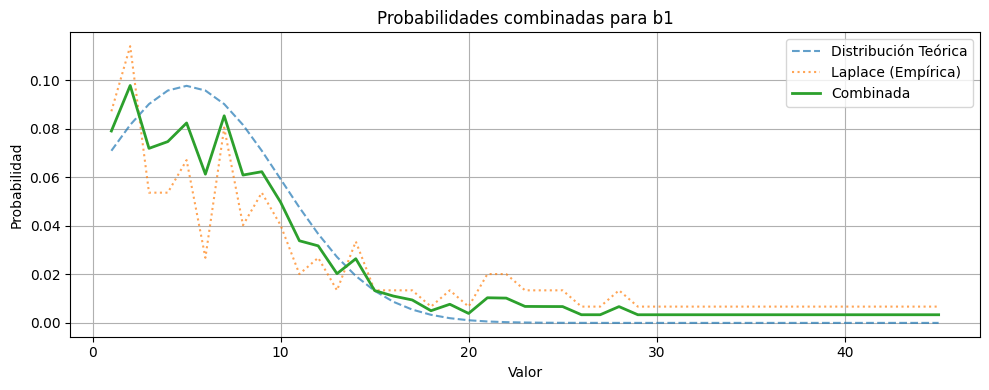

🎯 Siguientes valores más probables para b1:
  2: 0.0979
  7: 0.0854
  5: 0.0824
  1: 0.0791
  4: 0.0747
  3: 0.0720
  9: 0.0623
  6: 0.0613
  8: 0.0610
  10: 0.0498


In [24]:
b1_vals = next_gen_analyze("b1", body_size=104)

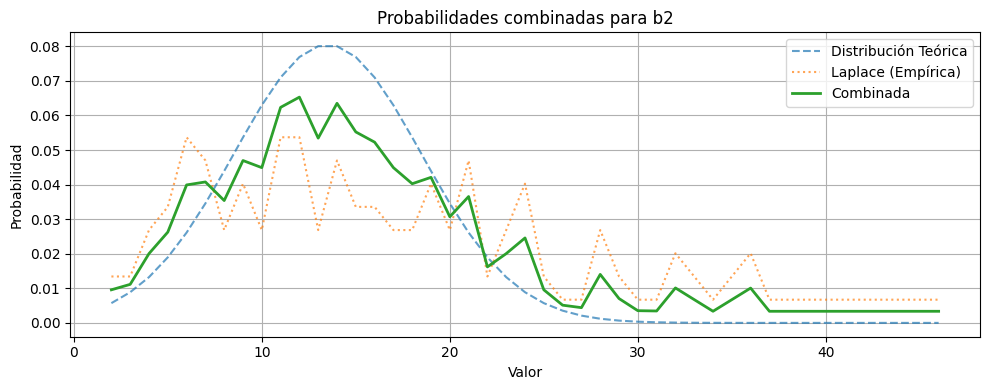

🎯 Siguientes valores más probables para b2:
  12: 0.0653
  14: 0.0635
  11: 0.0623
  15: 0.0552
  13: 0.0534
  16: 0.0523
  9: 0.0470
  10: 0.0449
  17: 0.0449
  19: 0.0421


In [25]:
b2_vals = next_gen_analyze("b2", body_size=104)

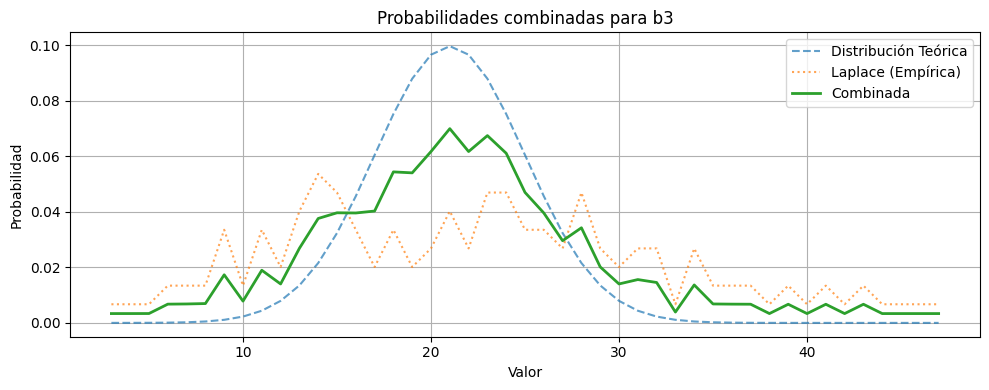

🎯 Siguientes valores más probables para b3:
  21: 0.0700
  23: 0.0675
  20: 0.0618
  22: 0.0618
  24: 0.0611
  18: 0.0544
  19: 0.0541
  25: 0.0470
  17: 0.0403
  15: 0.0397


In [26]:
b3_vals = next_gen_analyze("b3", body_size=104)

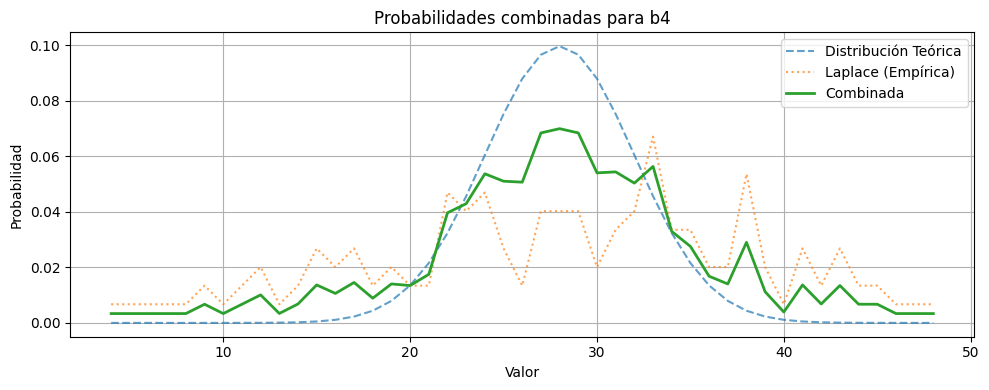

🎯 Siguientes valores más probables para b4:
  28: 0.0700
  27: 0.0685
  29: 0.0685
  33: 0.0564
  31: 0.0544
  30: 0.0541
  24: 0.0537
  25: 0.0511
  26: 0.0507
  32: 0.0504


In [27]:
b4_vals = next_gen_analyze("b4", body_size=104)

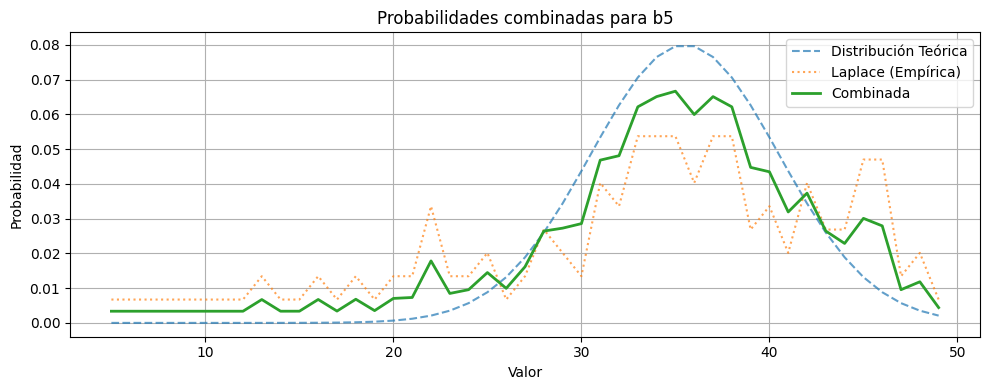

🎯 Siguientes valores más probables para b5:
  35: 0.0666
  34: 0.0651
  37: 0.0651
  33: 0.0621
  38: 0.0621
  36: 0.0599
  32: 0.0481
  31: 0.0468
  39: 0.0447
  40: 0.0435


In [28]:
b5_vals = next_gen_analyze("b5", body_size=104)

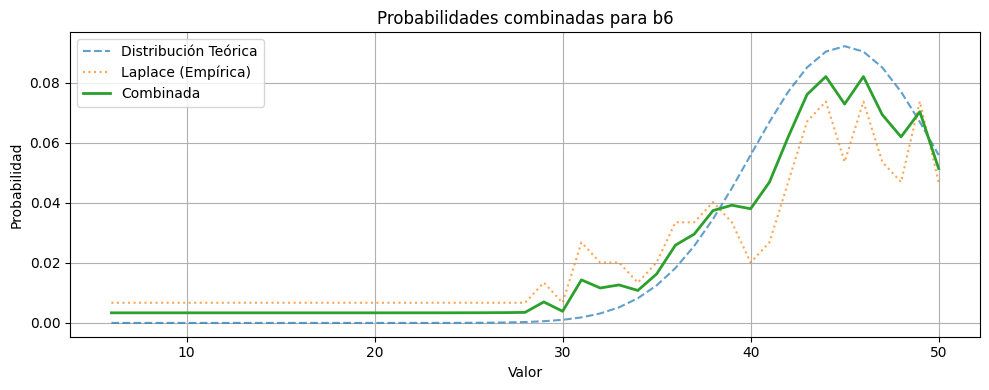

🎯 Siguientes valores más probables para b6:
  44: 0.0821
  46: 0.0821
  43: 0.0761
  45: 0.0730
  49: 0.0704
  47: 0.0694
  42: 0.0620
  48: 0.0620
  50: 0.0515
  41: 0.0469


In [29]:
b6_vals = next_gen_analyze("b6", body_size=104)